In [75]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from wordcloud import WordCloud
import string
import re
import nltk
nltk.download('punkt')
nltk.download('stopwords')
from nltk.corpus import stopwords

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\User\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\User\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [77]:
from nltk.probability import FreqDist
import pymorphy3

In [79]:
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.decomposition import LatentDirichletAllocation
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import NMF

In [7]:
with open('2011.txt', 'r') as file:
    data = file.read()

In [9]:
stop_words = stopwords.words('russian')
morph = pymorphy3.MorphAnalyzer()

In [11]:
def tokenize_text(raw_text: str):
    """Функция для токенизации текста
    :param raw_text: исходная текстовая строка
    """
    # Разбиение на сслова при помощи пробела
    words = raw_text.split()
    # Подготовка регулярного выражения для фильтрации символов
    re_punc = re.compile('[%s]' % re.escape(string.punctuation))
    # Удаление знаков препинания
    stripped = [re_punc.sub('', w) for w in words]
    # Приведение всех слов к нижнему регистру
    words_lower = [w.lower() for w in stripped]
    # Удаление оставшихся токенов, которые не являются буквами
    words_alpha = [word for word in words_lower if word.isalpha()]
    # Удаление стоп-слов    
    words_stop = [w for w in words_alpha if not w in stop_words]
    # Лемматизация    
    tokens = [morph.parse(token)[0].normal_form for token in words_stop]
    # Удалим короткие токены
    tokens = [word for word in tokens if len(word) > 2]
      
    return tokens

In [13]:
tokens2011 = tokenize_text(data)

In [15]:
with open('2012.txt', 'r') as file:
    data = file.read()
tokens2012 = tokenize_text(data)

In [17]:
with open('2013.txt', 'r') as file:
    data = file.read()
tokens2013 = tokenize_text(data)

In [19]:
with open('2014.txt', 'r') as file:
    data = file.read()
tokens2014 = tokenize_text(data)

In [20]:
with open('2015.txt', 'r') as file:
    data = file.read()
tokens2015 = tokenize_text(data)

In [23]:
with open('2016.txt', 'r') as file:
    data = file.read()
tokens2016 = tokenize_text(data)

In [24]:
with open('2017.txt', 'r') as file:
    data = file.read()
tokens2017 = tokenize_text(data)

In [25]:
with open('2018.txt', 'r') as file:
    data = file.read()
tokens2018 = tokenize_text(data)

In [27]:
with open('2019.txt', 'r') as file:
    data = file.read()
tokens2019 = tokenize_text(data)

In [30]:
with open('2020.txt', 'r') as file:
    data = file.read()
tokens2020 = tokenize_text(data)

In [31]:
with open('2021.txt', 'r') as file:
    data = file.read()
tokens2021 = tokenize_text(data)

In [33]:
with open('2022.txt', 'r') as file:
    data = file.read()
tokens2022 = tokenize_text(data)

In [35]:
with open('2023.txt', 'r') as file:
    data = file.read()
tokens2023 = tokenize_text(data)

In [37]:
with open('2024.txt', 'r') as file:
    data = file.read()
tokens2024 = tokenize_text(data)

In [41]:
tokens = tokens2011+tokens2012+tokens2013+tokens2014+tokens2015+tokens2016+tokens2017+tokens2018+tokens2019+tokens2020+tokens2021+tokens2022+tokens2023+tokens2024

In [45]:
all_words = FreqDist(tokens)

In [47]:
print("Наиболлее популярные слова: ", all_words.most_common(100))
print("\nОбщее количество уникальных слов: ", len(all_words.keys()))

Наиболлее популярные слова:  [('брикс', 2369), ('страна', 1760), ('сотрудничество', 1022), ('развитие', 974), ('международный', 777), ('год', 706), ('также', 665), ('область', 630), ('встреча', 594), ('вопрос', 591), ('цель', 561), ('оон', 506), ('приветствовать', 479), ('наш', 470), ('безопасность', 463), ('устойчивый', 386), ('который', 383), ('рамка', 382), ('подчёркивать', 369), ('обеспечение', 360), ('группа', 352), ('сфера', 348), ('призывать', 342), ('глобальный', 330), ('укрепление', 320), ('усилие', 318), ('экономический', 317), ('отмечать', 314), ('государство', 309), ('связь', 305), ('министр', 304), ('роль', 297), ('создание', 290), ('подтверждать', 290), ('вновь', 274), ('рабочий', 268), ('мир', 264), ('право', 259), ('число', 256), ('включая', 254), ('экономика', 253), ('важность', 252), ('использование', 251), ('проведение', 251), ('решение', 246), ('организация', 244), ('борьба', 243), ('система', 238), ('поддерживать', 234), ('совместный', 234), ('признать', 234), ('не

C:\Temp\ipykernel_6804\1563493910.py:7: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45)


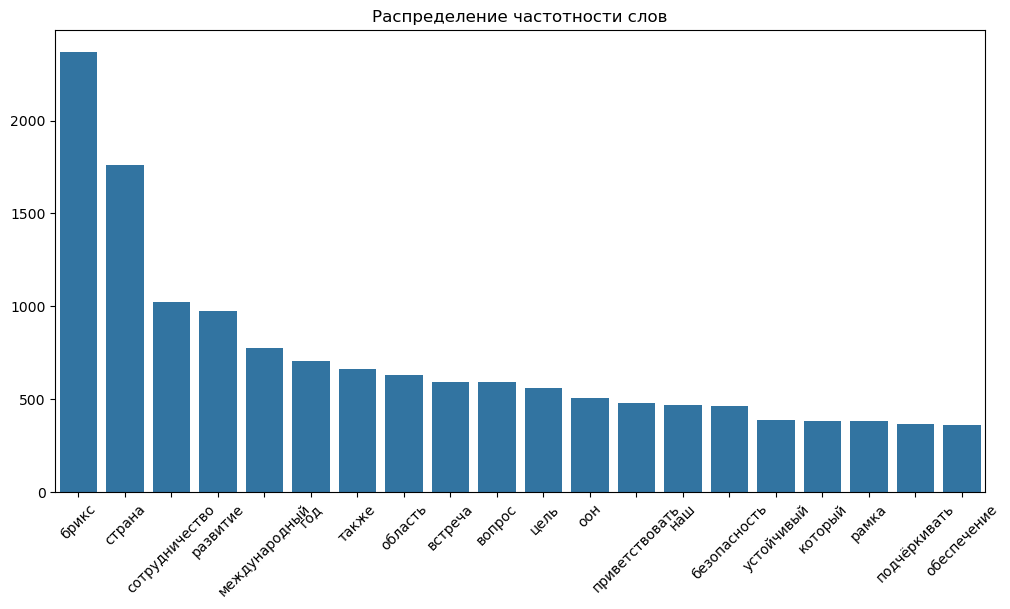

In [49]:
count, words = [], []
for w in all_words.most_common(20):
    words.append(w[0])
    count.append(w[1])
fig,ax = plt.subplots(figsize = (12,6))
ax = sns.barplot(x=words,y=count)
ax.set_xticklabels(ax.get_xticklabels(), rotation=45)
ax.set_title ('Распределение частотности слов')
plt.show()

In [51]:
stop_words_ex = ['год','наш', 'который', 'также']
def stop_words_extra(text):
    return [w for w in text if not w in stop_words_ex]

In [53]:
tokens = stop_words_extra(tokens)

C:\Temp\ipykernel_6804\3051857113.py:8: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45)


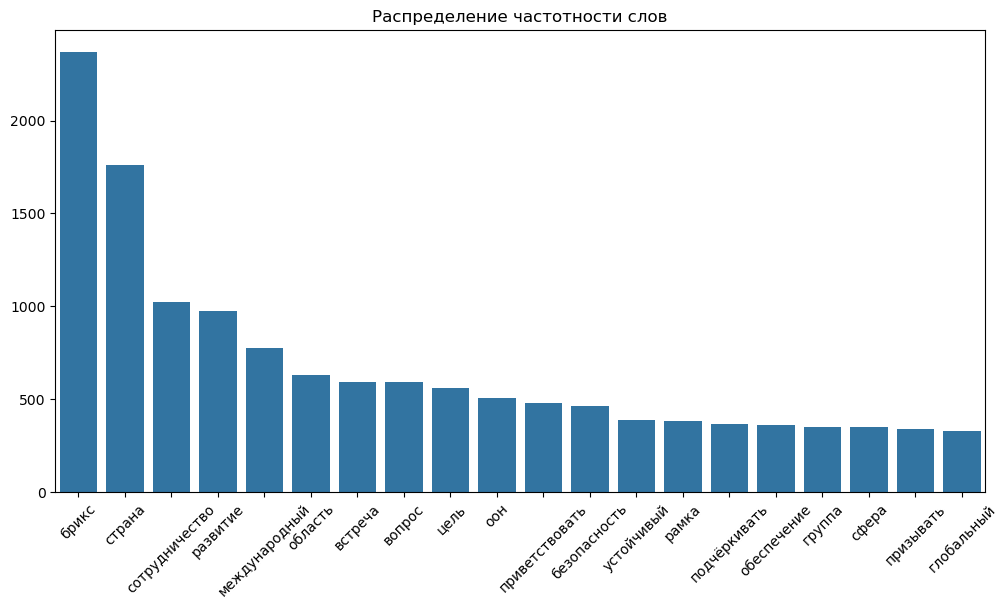

In [55]:
all_words = FreqDist(tokens)
count, words = [], []
for w in all_words.most_common(20):
    words.append(w[0])
    count.append(w[1])
fig,ax = plt.subplots(figsize = (12,6))
ax = sns.barplot(x=words,y=count)
ax.set_xticklabels(ax.get_xticklabels(), rotation=45)
ax.set_title ('Распределение частотности слов')
plt.show()

In [57]:
textt = ','.join(w for w in tokens)

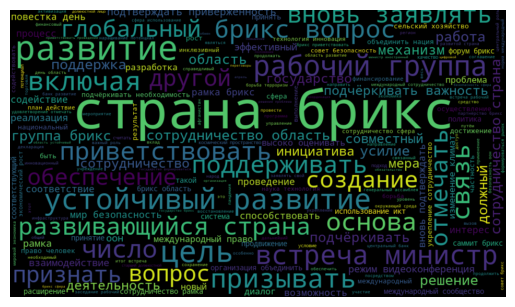

In [59]:
wordcloud = WordCloud(width=950,height=550).generate(textt)
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis("off")
plt.show()

In [61]:
# Приводим текст в векторное представление
tfidf_vect = TfidfVectorizer(max_df=1.0, min_df=2, stop_words=None)
doc_term_matrix = tfidf_vect.fit_transform(tokens)

### Латентное размещение Дерихле

In [64]:
LDA = LatentDirichletAllocation(n_components=2, random_state=42)
LDA.fit(doc_term_matrix)

LatentDirichletAllocation(n_components=2, random_state=42)

In [65]:
for i,topic in enumerate(LDA.components_):
    print(f'Top 10 words for topic #{i}:')
    print([tfidf_vect.get_feature_names_out()[i] for i in topic.argsort()[-10:]])
    print('\n')

Top 10 words for topic #0:
['глобальный', 'сфера', 'группа', 'подчёркивать', 'оон', 'вопрос', 'встреча', 'область', 'международный', 'сотрудничество']


Top 10 words for topic #1:
['призывать', 'обеспечение', 'рамка', 'устойчивый', 'безопасность', 'приветствовать', 'цель', 'развитие', 'страна', 'брикс']




In [66]:
LDA = LatentDirichletAllocation(n_components=3, random_state=42)
LDA.fit(doc_term_matrix)
for i,topic in enumerate(LDA.components_):
    print(f'Top 10 words for topic #{i}:')
    print([tfidf_vect.get_feature_names_out()[i] for i in topic.argsort()[-10:]])
    print('\n')

Top 10 words for topic #0:
['важность', 'экономика', 'государство', 'сфера', 'подчёркивать', 'вопрос', 'встреча', 'область', 'международный', 'сотрудничество']


Top 10 words for topic #1:
['связь', 'отмечать', 'экономический', 'укрепление', 'устойчивый', 'безопасность', 'приветствовать', 'оон', 'развитие', 'брикс']


Top 10 words for topic #2:
['вновь', 'подтверждать', 'усилие', 'глобальный', 'призывать', 'группа', 'обеспечение', 'рамка', 'цель', 'страна']




In [67]:
LDA = LatentDirichletAllocation(n_components=4, random_state=42)
LDA.fit(doc_term_matrix)
for i,topic in enumerate(LDA.components_):
    print(f'Top 10 words for topic #{i}:')
    print([tfidf_vect.get_feature_names_out()[i] for i in topic.argsort()[-10:]])
    print('\n')

Top 10 words for topic #0:
['приверженность', 'совет', 'новый', 'технология', 'важность', 'экономика', 'государство', 'встреча', 'область', 'сотрудничество']


Top 10 words for topic #1:
['рабочий', 'создание', 'роль', 'министр', 'отмечать', 'экономический', 'устойчивый', 'приветствовать', 'оон', 'брикс']


Top 10 words for topic #2:
['число', 'мир', 'вновь', 'подтверждать', 'усилие', 'глобальный', 'призывать', 'обеспечение', 'рамка', 'цель']


Top 10 words for topic #3:
['связь', 'укрепление', 'сфера', 'группа', 'подчёркивать', 'безопасность', 'вопрос', 'международный', 'развитие', 'страна']




In [68]:
LDA = LatentDirichletAllocation(n_components=5, random_state=42)
LDA.fit(doc_term_matrix)
for i,topic in enumerate(LDA.components_):
    print(f'Top 10 words for topic #{i}:')
    print([tfidf_vect.get_feature_names_out()[i] for i in topic.argsort()[-10:]])
    print('\n')

Top 10 words for topic #0:
['достижение', 'основа', 'приверженность', 'совет', 'новый', 'технология', 'важность', 'экономика', 'государство', 'встреча']


Top 10 words for topic #1:
['поддержка', 'совместный', 'борьба', 'право', 'создание', 'роль', 'министр', 'экономический', 'устойчивый', 'брикс']


Top 10 words for topic #2:
['проведение', 'число', 'мир', 'вновь', 'подтверждать', 'усилие', 'глобальный', 'обеспечение', 'рамка', 'цель']


Top 10 words for topic #3:
['необходимость', 'решение', 'использование', 'связь', 'сфера', 'группа', 'подчёркивать', 'международный', 'развитие', 'страна']


Top 10 words for topic #4:
['рабочий', 'отмечать', 'укрепление', 'призывать', 'безопасность', 'приветствовать', 'оон', 'вопрос', 'область', 'сотрудничество']




### Неотрицательная матричная факторизация

In [ ]:
nmf = NMF(n_components=2, random_state=42)
nmf.fit(doc_term_matrix )
for i,topic in enumerate(nmf.components_):
    print(f'Top 10 words for topic #{i}:')
    print([tfidf_vect.get_feature_names_out()[i] for i in topic.argsort()[-10:]])
    print('\n')

Вывод: тематика обсуждаемых на саммитах тем преимущественно связана исключительно с проблемами глобального развития и международного сотрудничества